In [3]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [4]:
# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\angel\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\angel\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\angel\AppData\Roaming\nltk_data...


True

In [6]:
df=pd.read_csv(r"C:\Users\angel\OneDrive\Documents\zomato-ipo1.csv")
print(df.head())


     Unnamed: 0            id               created_at        date      time  \
0  1.415520e+18  1.415520e+18  2021-07-15 04:04:31 UTC  15-07-2021  04:04:31   
1  1.415520e+18  1.415520e+18  2021-07-15 04:03:51 UTC  15-07-2021  04:03:51   
2  1.415520e+18  1.415520e+18  2021-07-15 04:03:48 UTC  15-07-2021  04:03:48   
3  1.415520e+18  1.415520e+18  2021-07-15 04:03:05 UTC  15-07-2021  04:03:05   
4  1.415520e+18  1.415520e+18  2021-07-15 04:02:51 UTC  15-07-2021  04:02:51   

   timezone       user_id         username                          name  \
0         0  1.343230e+18  thakura47791042                    Aman Singh   
1         0  1.312270e+18      tripurateer                   TRIPURATEER   
2         0  1.321160e+18    ankitkakkad11                  Ankit Kakkad   
3         0  9.906568e+07       schandra78               Saurabh Chandra   
4         0  1.693991e+09           silelf  Dr. Silvia Elaluf-Calderwood   

  place  ... geo source user_rt_id user_rt retweet_id  \
0   N

In [7]:
print(df.shape)

(11494, 36)


In [8]:
df.columns

Index(['Unnamed: 0', 'id', 'created_at', 'date', 'time', 'timezone', 'user_id',
       'username', 'name', 'place', 'tweet', 'language', 'mentions', 'urls',
       'photos', 'replies_count', 'retweets_count', 'likes_count', 'hashtags',
       'cashtags', 'link', 'retweet', 'quote_url', 'video', 'thumbnail',
       'near', 'geo', 'source', 'user_rt_id', 'user_rt', 'retweet_id',
       'reply_to', 'retweet_date', 'translate', 'trans_src', 'trans_dest'],
      dtype='str')

In [9]:
df.isnull().sum()

Unnamed: 0            0
id                    0
created_at            0
date                  0
time                  0
timezone              0
user_id               0
username              0
name                  1
place             11485
tweet                 0
language              0
mentions              0
urls                  0
photos                0
replies_count         0
retweets_count        0
likes_count           0
hashtags              0
cashtags              0
link                  0
retweet               0
quote_url         10604
video                 0
thumbnail          8846
near              11494
geo               11494
source            11494
user_rt_id        11494
user_rt           11494
retweet_id        11494
reply_to              0
retweet_date      11494
translate         11494
trans_src         11494
trans_dest        11494
dtype: int64

In [10]:
cols_to_drop = [
    'Unnamed: 0', 'near', 'geo', 'source',
    'user_rt_id', 'user_rt', 'retweet_id',
    'retweet_date', 'translate', 'trans_src', 'trans_dest',
    'thumbnail', 'place'
]

In [11]:
df.drop(columns=cols_to_drop, inplace=True)
print("\nAfter dropping irrelevant columns:", df.shape)


After dropping irrelevant columns: (11494, 23)


In [12]:
df['name'] = df['name'].fillna(df['username'])

In [13]:
df['quote_url'] = df['quote_url'].fillna('')

In [14]:
print("\nMissing values after handling:\n", df.isnull().sum())


Missing values after handling:
 id                0
created_at        0
date              0
time              0
timezone          0
user_id           0
username          0
name              0
tweet             0
language          0
mentions          0
urls              0
photos            0
replies_count     0
retweets_count    0
likes_count       0
hashtags          0
cashtags          0
link              0
retweet           0
quote_url         0
video             0
reply_to          0
dtype: int64


In [16]:
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['retweet'] = df['retweet'].astype(bool)
df['video'] = df['video'].astype(int)

print("\nData types:\n", df.dtypes)


Data types:
 id                            float64
created_at        datetime64[us, UTC]
date                   datetime64[us]
time                              str
timezone                        int64
user_id                       float64
username                          str
name                              str
tweet                             str
language                          str
mentions                          str
urls                              str
photos                            str
replies_count                   int64
retweets_count                  int64
likes_count                     int64
hashtags                          str
cashtags                          str
link                              str
retweet                          bool
quote_url                         str
video                           int64
reply_to                          str
dtype: object


In [17]:
before = len(df)
df.drop_duplicates(subset='id', inplace=True)
print(f"\nDuplicates removed: {before - len(df)}, Remaining rows: {len(df)}")


Duplicates removed: 10376, Remaining rows: 1118


In [18]:
before = len(df)
df = df[df['language'] == 'en'].reset_index(drop=True)
print(f"\nNon-English tweets removed: {before - len(df)}, Remaining: {len(df)}")


Non-English tweets removed: 168, Remaining: 950


In [19]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    """Full text cleaning pipeline."""
    if not isinstance(text, str):
        return ""
    text = text.lower()                                          # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)                 # Remove URLs
    text = re.sub(r'@\w+', '', text)                           # Remove mentions
    text = re.sub(r'#(\w+)', r'\1', text)                      # Remove # but keep word
    text = re.sub(r'[^\x00-\x7F]+', '', text)                  # Remove non-ASCII
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)                            # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()                   # Normalize whitespace
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

In [20]:
df['cleaned_tweet'] = df['tweet'].apply(clean_tweet)

In [21]:
df = df[df['cleaned_tweet'].str.strip() != ''].reset_index(drop=True)
print(f"\nRows after removing empty cleaned tweets: {len(df)}")


Rows after removing empty cleaned tweets: 950


In [22]:
# Ensure 'created_at' is datetime type, as previous steps might have been skipped or undone.
if not pd.api.types.is_datetime64_any_dtype(df['created_at']):
    df['created_at'] = pd.to_datetime(df['created_at'], utc=True)

df['tweet_length']        = df['tweet'].apply(len)
df['cleaned_length']      = df['cleaned_tweet'].apply(len)
df['word_count']          = df['cleaned_tweet'].apply(lambda x: len(x.split()))
df['has_url']             = df['urls'].apply(lambda x: 1 if x != '[]' else 0)
df['has_mention']         = df['mentions'].apply(lambda x: 1 if x != '[]' else 0)
df['has_hashtag']         = df['hashtags'].apply(lambda x: 1 if x != '[]' else 0)
df['hour']                = df['created_at'].dt.hour
df['day_of_week']         = df['created_at'].dt.day_name()
df['engagement_score']    = df['replies_count'] + df['retweets_count'] + df['likes_count']

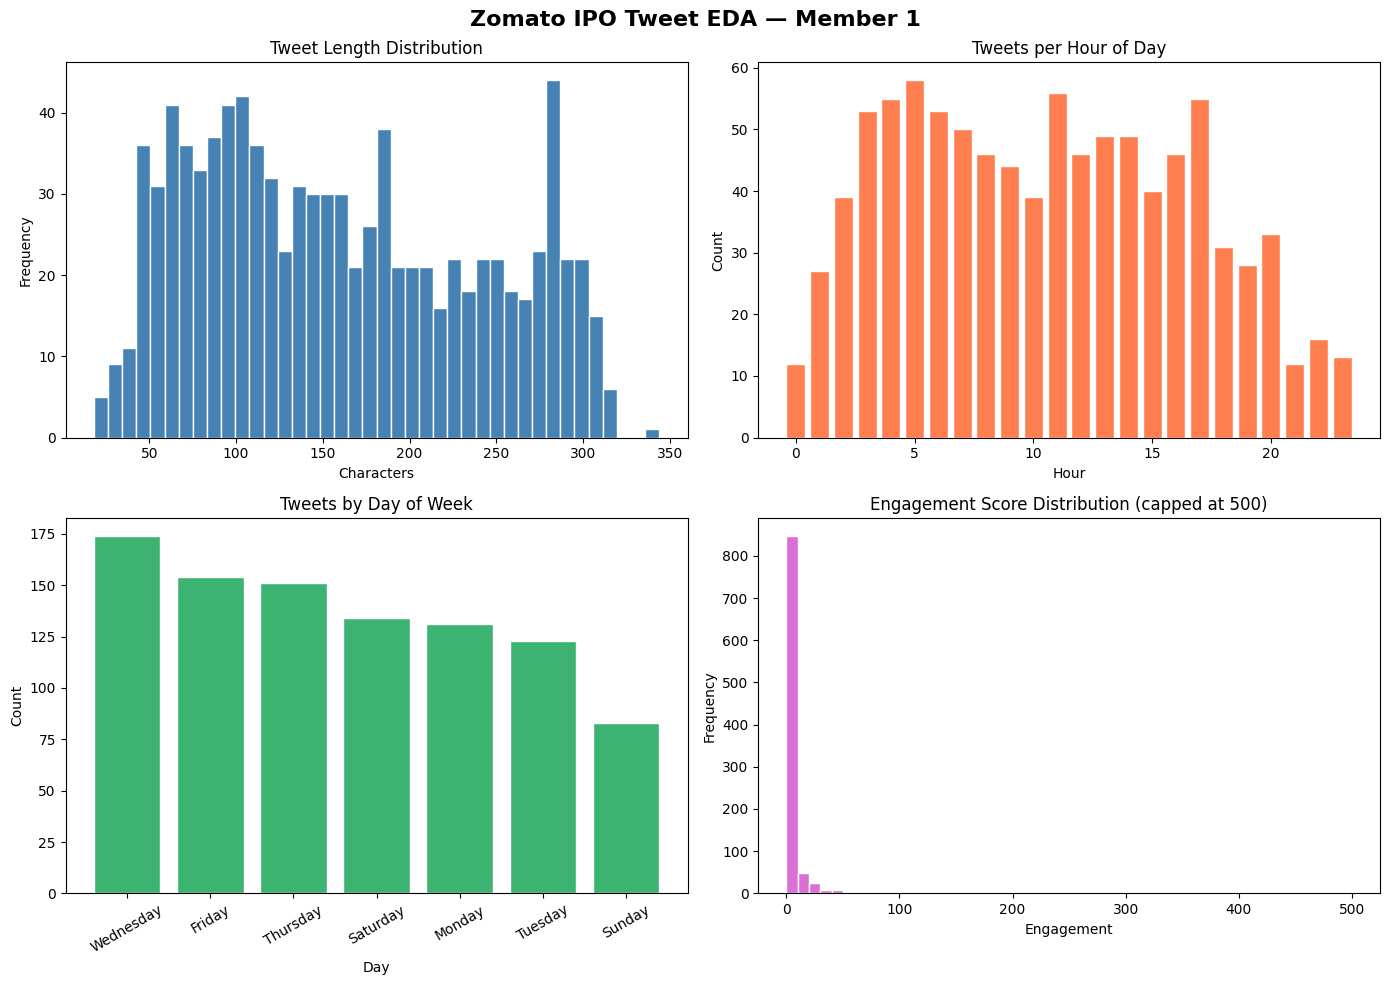

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Zomato IPO Tweet EDA — Member 1", fontsize=16, fontweight='bold')

# Tweet length distribution
axes[0, 0].hist(df['tweet_length'], bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title("Tweet Length Distribution")
axes[0, 0].set_xlabel("Characters"); axes[0, 0].set_ylabel("Frequency")

# Tweets per hour
hourly = df['hour'].value_counts().sort_index()
axes[0, 1].bar(hourly.index, hourly.values, color='coral', edgecolor='white')
axes[0, 1].set_title("Tweets per Hour of Day")
axes[0, 1].set_xlabel("Hour"); axes[0, 1].set_ylabel("Count")

# Tweets by day of week
dow = df['day_of_week'].value_counts()
axes[1, 0].bar(dow.index, dow.values, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title("Tweets by Day of Week")
axes[1, 0].set_xlabel("Day"); axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis='x', rotation=30)

# Engagement score distribution (capped at 500)
axes[1, 1].hist(df['engagement_score'].clip(upper=500), bins=50, color='orchid', edgecolor='white')
axes[1, 1].set_title("Engagement Score Distribution (capped at 500)")
axes[1, 1].set_xlabel("Engagement"); axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("1_eda.png", dpi=150)
plt.show()